In [68]:
import pandas as pd

In [69]:
df = pd.read_csv("../data/raw/ds_salaries.csv")

In [70]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [71]:
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='str')

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [73]:
## Unnamed: 0 column
df.drop(columns = ["Unnamed: 0"], inplace = True)

In [74]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [75]:
# Convert experience labels 
df["experience_level"] = df["experience_level"].replace({
    "EN": "Entry",
    "MI": "Mid",
    "SE": "Senior",
    "EX": "Executive"
})

In [76]:
df["experience_level"].unique()

<StringArray>
['Mid', 'Senior', 'Entry', 'Executive']
Length: 4, dtype: str

In [77]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
order = ["Entry", "Mid", "Senior", "Executive"]

### Salary Distribution

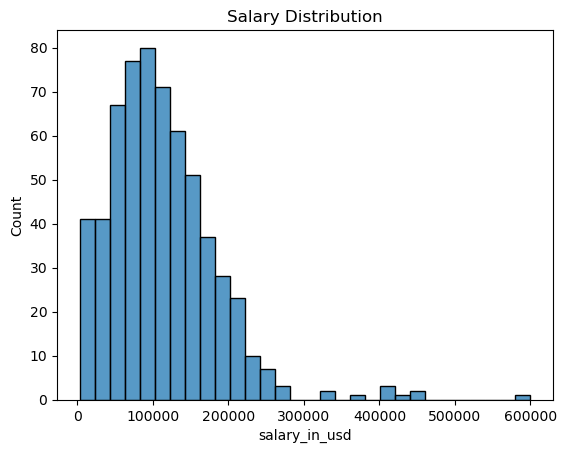

In [80]:

sns.histplot(df["salary_in_usd"], bins = 30)
plt.title("Salary Distribution")
plt.show()

Insight : 
- The salary distribution is right-skewed, meaning most professionals earn lower to mid-range salaries.
- A large concentration of salaries lies between $50,000 and $150,000.
- There are a few high-paying outliers (above $300,000), indicating that top roles or specialized positions earn significantly more.

### Salary vs Experience

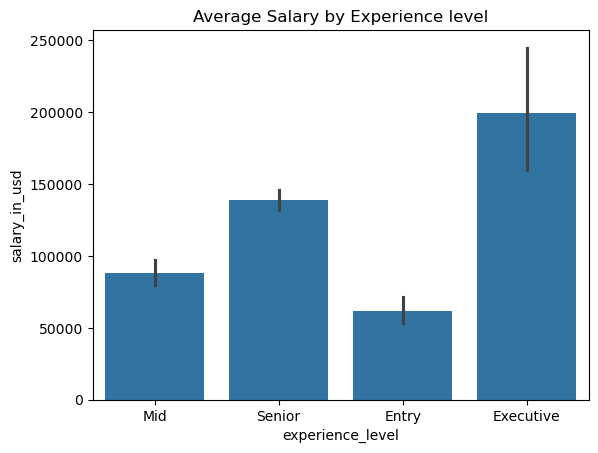

In [81]:
## Barplot :
sns.barplot(x = "experience_level", y = "salary_in_usd", data = df)
plt.title("Average Salary by Experience level")
plt.show()

Insight:

- Executive (EX) roles have the highest average salary, followed by Senior (SE), Mid-level (MI), and Entry-level (EN).
- There is a clear upward trend in salary as experience level increases.
- Entry-level professionals earn significantly less compared to mid and senior roles.

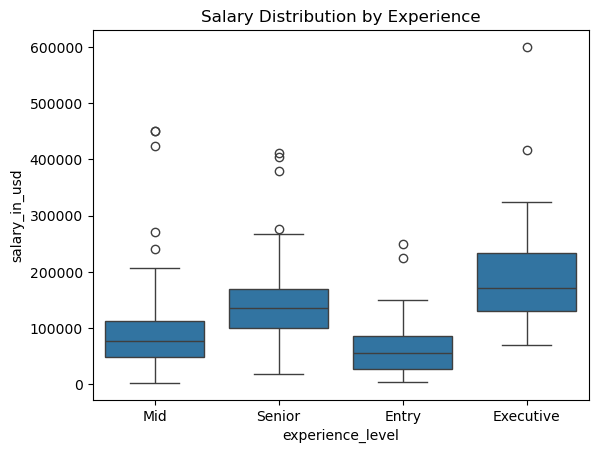

In [82]:
## Boxplot :
sns.boxplot(x = "experience_level", y = "salary_in_usd", data = df)
plt.title("Salary Distribution by Experience")
plt.show()

Insight:

- Salary distribution shifts upward with increasing experience level, with Executive roles having the highest median salaries.
- Entry-level roles have a lower and tighter salary range, indicating less variation in pay.
- Senior and Executive roles show a wider spread, suggesting higher variability and presence of high-paying opportunities.
- Several high-value outliers exist, especially in Senior and Executive levels, indicating top-paying roles in the market.

### 2. Salary vs Company Size

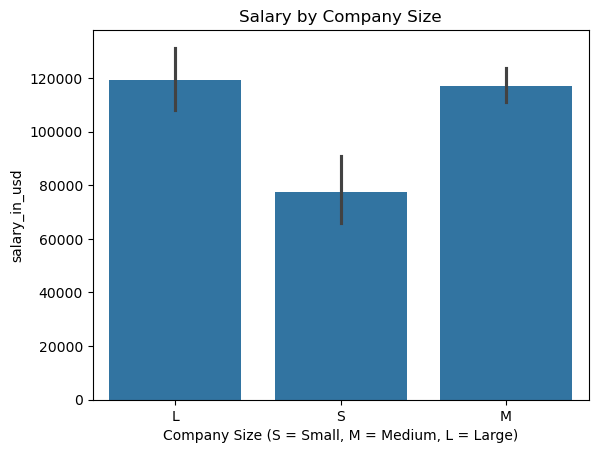

In [88]:
sns.barplot(x = "company_size", y = "salary_in_usd", data = df)
plt.title("Salary by Company Size")
plt.xlabel("Company Size (S = Small, M = Medium, L = Large)")
plt.show()

Insight:

- Large (L) and Medium (M) companies offer higher average salaries compared to Small (S) companies.
- Small companies tend to have noticeably lower salary offerings.
- The salary difference between Medium and Large companies is relatively small, suggesting both offer competitive pay.
- Overall, company size has a visible impact on salary, with larger organizations generally paying more.

### Salary by Country (Top 10)

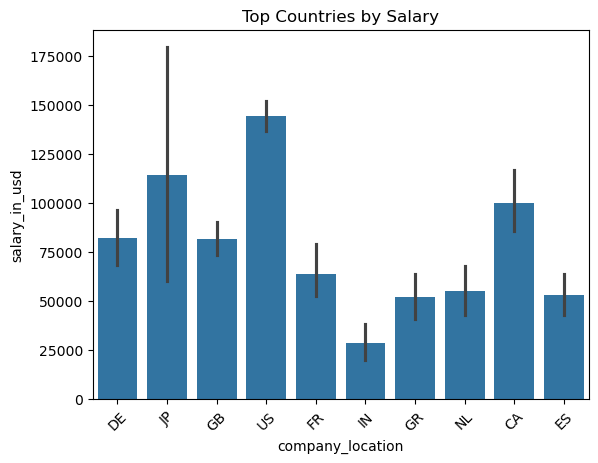

In [84]:
top_countries = df["company_location"].value_counts().head(10).index

sns.barplot(
    data = df[df["company_location"].isin(top_countries)],
    x = "company_location",
    y = "salary_in_usd"
)
plt.title("Top Countries by Salary")
plt.xticks(rotation = 45)
plt.show()

Insight:

- The United States offers the highest average salaries among the top countries, indicating strong demand and higher compensation standards in its data job market.
- Countries like India show significantly lower average salaries, reflecting regional economic differences and cost of living variations.
- European countries such as Germany (DE), France (FR), and Spain (ES) fall in the mid-range, offering moderate salary levels.
- Overall, salary distribution varies widely across countries, highlighting the importance of location in determining compensation.

### Remote Work Impact

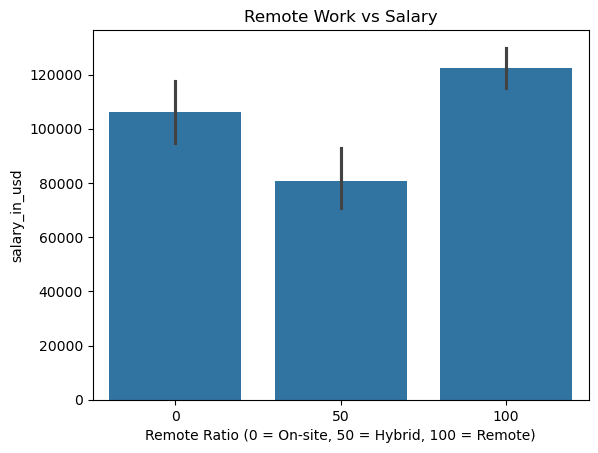

In [85]:
sns.barplot(x = "remote_ratio", y = "salary_in_usd", data = df)
plt.title("Remote Work vs Salary")
plt.xlabel("Remote Ratio (0 = On-site, 50 = Hybrid, 100 = Remote)")
plt.show()

Insight:

- Fully remote roles (100% remote) tend to offer the highest average salaries, indicating strong demand and flexibility benefits.
- Hybrid roles (50% remote) show comparatively lower salaries, suggesting they may not offer the same advantages as fully remote positions.
- On-site roles (0% remote) still provide competitive salaries but fall below fully remote roles.
- Overall, remote work appears to have a positive impact on salary, with fully remote positions being the most rewarding.

### Salary Trend Over Time

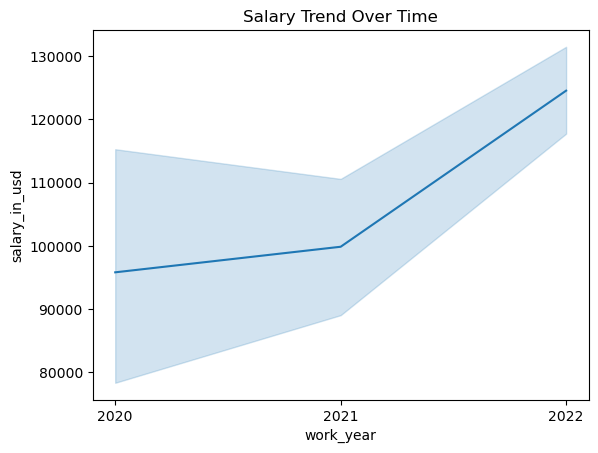

In [89]:
sns.lineplot(x = "work_year", y = "salary_in_usd", data = df)
plt.xticks([2020, 2021, 2022])
plt.title("Salary Trend Over Time")
plt.show()

Insight:

- Average salaries show a consistent upward trend over the years, indicating growing demand in the data job market.
- There is a moderate increase from 2020 to 2021, followed by a more noticeable rise in 2022.
- The increase in recent years suggests higher market value for data professionals and expanding opportunities in the field. 

### Correlation

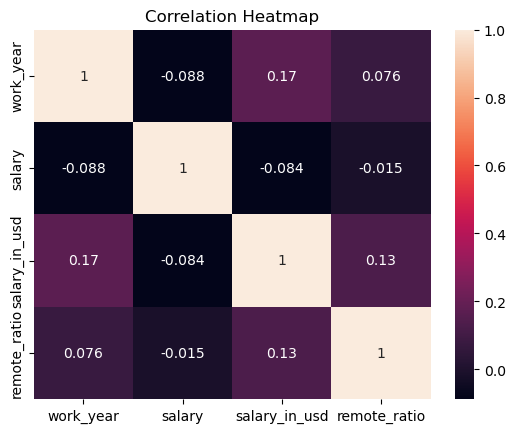

In [87]:
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title("Correlation Heatmap")
plt.show()

Insight:

- Most variables show weak or near-zero correlation with salary, indicating that no single numeric factor strongly determines salary in this dataset.
- Work year has a slight positive correlation with salary, suggesting that salaries have increased over time.
- Remote ratio shows a very weak positive relationship with salary, indicating that remote work may have a minor influence on compensation.
- The strong correlation between salary and salary_in_usd is expected, as they represent the same values in different currencies.

## Conclusion

- Experience level is the most significant factor influencing salary, with Executive and Senior roles earning substantially higher than Entry and Mid-level positions.
- Company size also impacts compensation, as Medium and Large companies generally offer higher salaries compared to Small companies.
- Salaries vary significantly across countries, with the United States offering the highest average compensation, while some countries show comparatively lower salary levels due to economic differences.
- Remote work has a positive influence on salary, with fully remote roles offering higher average pay compared to hybrid and on-site roles.
- Salary trends over time show a consistent increase, indicating growing demand and value for data professionals in recent years.
- Correlation analysis reveals that numeric variables alone do not strongly determine salary, suggesting that categorical factors like experience, location, and company size play a more important role.

### Overall Insight:
The data suggests that the data job market is growing, with increasing salaries, strong demand for experienced professionals, and evolving work models such as remote work contributing to higher compensation.